# Cytotoxicity Dataset: EDA and Baseline Models

Exploratory analysis of the combined cytotoxicity classification dataset, then baseline models built up one at a time: Logistic Regression → Random Forest → XGBoost → TabPFN → CheMeleon → DeepTox-style DNN.

## 1. Setup and load data

Note: as of this run, `data/combined/` contains **Tox21 + ToxCast only** — GDSC is still being resolved in the background (drug-name → PubChem CID lookup) and will be folded in once ready. Re-run this cell after that to pick it up automatically.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

REPO_ROOT = "/home/ak/repos/cytotoxicity-dataset-collection"
df = pd.read_csv(f"{REPO_ROOT}/data/combined/combined_cytotoxicity_classification.csv")
print(df.shape)
df.head()

(15476, 14)


,source,biological_context,cid,canonical_smiles,isomeric_smiles,molecular_formula,molecular_weight,cytotoxic_label,potency_value,potency_metric,potency_unit,n_assays_active,n_assays_tested,assay_description
0,Tox21,off-target-safety,4,CC(CN)O,CC(CN)O,C3H9NO,75.11,0.0,NaN,AC50,uM,0.0,4.0,RealTime-Glo MT Cell Viability + CellTox Green...
1,Tox21,off-target-safety,6,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,C6H3ClN2O4,202.55,1.0,9.9244,AC50,uM,8.0,8.0,RealTime-Glo MT Cell Viability + CellTox Green...
2,Tox21,off-target-safety,11,C(CCl)Cl,C(CCl)Cl,C2H4Cl2,98.96,0.0,NaN,AC50,uM,0.0,4.0,RealTime-Glo MT Cell Viability + CellTox Green...
3,Tox21,off-target-safety,13,C1=CC(=C(C=C1Cl)Cl)Cl,C1=CC(=C(C=C1Cl)Cl)Cl,C6H3Cl3,181.40,0.0,NaN,AC50,uM,0.0,8.0,RealTime-Glo MT Cell Viability + CellTox Green...
4,Tox21,off-target-safety,33,C(C=O)Cl,C(C=O)Cl,C2H3ClO,78.50,0.0,NaN,AC50,uM,0.0,4.0,RealTime-Glo MT Cell Viability + CellTox Green...


## 2. Source and biological context breakdown

Recall: `biological_context` distinguishes off-target safety toxicity (Tox21/ToxCast) from on-target cancer-efficacy killing (GDSC and future additions) — these should not be pooled into one label without accounting for this.

In [2]:
print(df.groupby(["source", "biological_context"]).size())
print()
print("Rows with missing SMILES:", df["canonical_smiles"].isna().sum())
print("Unique compounds (CID) overall:", df["cid"].nunique())
print("Unique compounds per source:")
print(df.groupby("source")["cid"].nunique())

source   biological_context
Tox21    off-target-safety     7671
ToxCast  off-target-safety     7805
dtype: int64

Rows with missing SMILES: 0
Unique compounds (CID) overall: 9147
Unique compounds per source:
source
Tox21      7671
ToxCast    7762
Name: cid, dtype: int64


## 3. Class balance — overall and by source

`cytotoxic_label` has NaN rows (inconclusive, Tox21 only) — drop those before any modeling.

Rows usable for modeling (non-null label + SMILES): 14105 / 15476


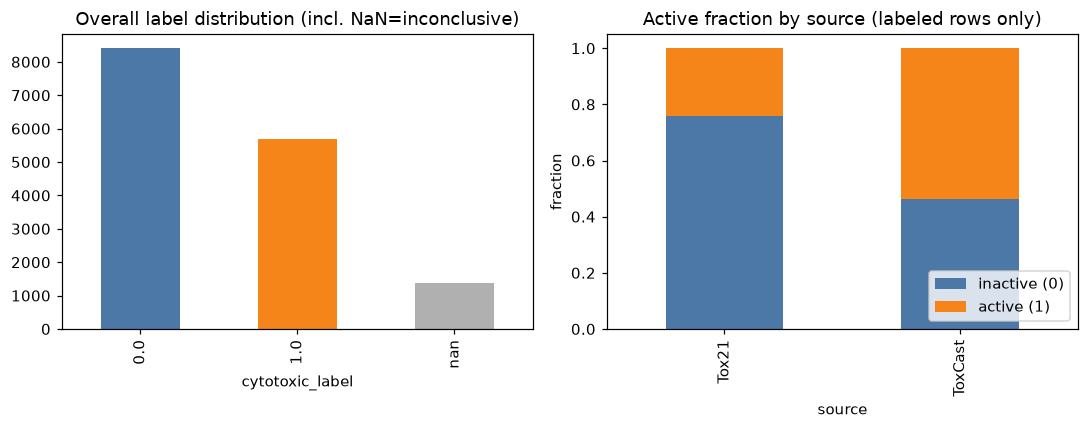

cytotoxic_label     0     1
source                     
Tox21            4788  1512
ToxCast          3621  4184


In [3]:
labeled = df.dropna(subset=["cytotoxic_label", "canonical_smiles"]).copy()
labeled["cytotoxic_label"] = labeled["cytotoxic_label"].astype(int)
print(f"Rows usable for modeling (non-null label + SMILES): {len(labeled)} / {len(df)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["cytotoxic_label"].value_counts(dropna=False).sort_index().plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#B0B0B0"])
axes[0].set_title("Overall label distribution (incl. NaN=inconclusive)")
axes[0].set_xlabel("cytotoxic_label")

ct = pd.crosstab(labeled["source"], labeled["cytotoxic_label"], normalize="index")
ct.plot(kind="bar", stacked=True, ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Active fraction by source (labeled rows only)")
axes[1].set_ylabel("fraction")
axes[1].legend(["inactive (0)", "active (1)"], loc="lower right")
plt.tight_layout()
plt.show()

print(pd.crosstab(labeled["source"], labeled["cytotoxic_label"]))

## 4. Molecular weight distribution by source

Sanity check on chemical space differences between the toxicology-screening sources (broad chemical libraries) and cancer-pharmacology sources (targeted drug libraries, once GDSC is added).

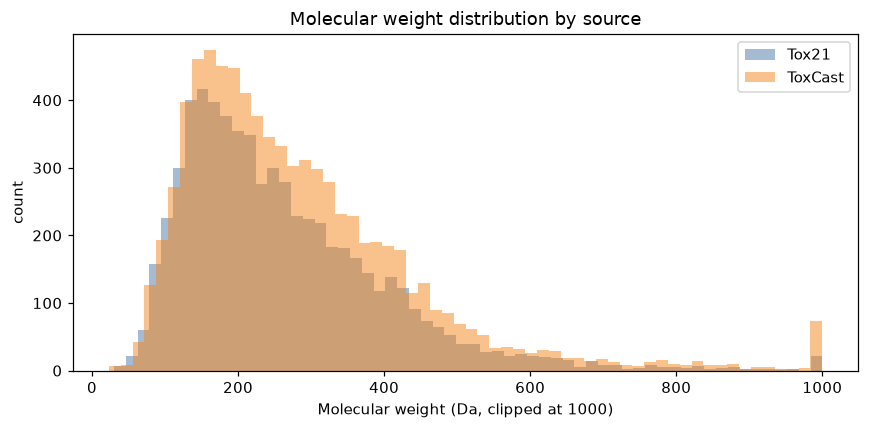

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
Tox21,6300.0,263.050272,147.452021,30.026000,158.28,229.07,331.575,1550.2
ToxCast,7805.0,285.812456,181.594975,22.989769,168.19,245.66,354.500,3326.8


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for src, color in zip(labeled["source"].unique(), ["#4C78A8", "#F58518", "#54A24B"]):
    subset = labeled.loc[labeled["source"] == src, "molecular_weight"].dropna()
    ax.hist(subset.clip(upper=1000), bins=60, alpha=0.5, label=src, color=color)
ax.set_xlabel("Molecular weight (Da, clipped at 1000)")
ax.set_ylabel("count")
ax.legend()
ax.set_title("Molecular weight distribution by source")
plt.tight_layout()
plt.show()

labeled.groupby("source")["molecular_weight"].describe()

## 5. Cross-source compound overlap

Same CID appearing under multiple sources means it carries a different label depending on which biological question was asked — worth knowing how much of the dataset this affects.

In [5]:
sources = labeled["source"].unique().tolist()
for i in range(len(sources)):
    for j in range(i + 1, len(sources)):
        a, b = sources[i], sources[j]
        cids_a = set(labeled.loc[labeled["source"] == a, "cid"])
        cids_b = set(labeled.loc[labeled["source"] == b, "cid"])
        overlap = cids_a & cids_b
        print(f"{a} ({len(cids_a)}) vs {b} ({len(cids_b)}): {len(overlap)} shared CIDs")

# For CIDs shared between two sources, how often do the labels actually disagree?
if len(sources) >= 2:
    pivot = labeled.pivot_table(index="cid", columns="source", values="cytotoxic_label", aggfunc="first")
    pair_cols = [c for c in pivot.columns if c in sources]
    if len(pair_cols) == 2:
        both = pivot.dropna(subset=pair_cols)
        agree = (both[pair_cols[0]] == both[pair_cols[1]]).mean()
        print(f"\nOf {len(both)} compounds labeled in both {pair_cols[0]} and {pair_cols[1]}: {agree:.1%} label agreement")

Tox21 (6300) vs ToxCast (7762): 5155 shared CIDs

Of 5155 compounds labeled in both Tox21 and ToxCast: 72.3% label agreement


### EDA takeaways

- **14,105 / 15,476 rows usable** (drop NaN labels — Tox21 inconclusive — and any missing SMILES).
- **Class balance differs sharply by source**: Tox21 ~20% active, ToxCast ~54% active — a model must not treat `source` as a nuisance column; it's informative and should be a feature or a stratification key.
- **5,155 compounds (CID) are shared** between Tox21 and ToxCast, but their labels agree only **72.3% of the time** — the two panels are measuring related but genuinely different things (dedicated 4-assay viability panel vs. cross-target burst pattern across ~86 assays), confirming they shouldn't be silently merged into one ground truth.
- Molecular weight distributions are similar between Tox21/ToxCast (both broad chemical libraries); this will likely diverge once GDSC (targeted oncology drugs) is added.

## 6. Featurization: Morgan fingerprints

Baseline models (LogReg, RF, XGBoost, TabPFN) will use ECFP4-style Morgan fingerprints (radius=2, 2048 bits) computed from `canonical_smiles` via RDKit. CheMeleon and the DeepTox-style DNN use their own representations (message-passing graph / a wider feature set respectively), built in their own sections later.

In [6]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

FP_RADIUS, FP_BITS = 2, 2048
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_BITS)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(fp_gen.GetFingerprint(mol))

unique_smiles = labeled["canonical_smiles"].unique()
fp_cache = {}
n_failed = 0
for smi in unique_smiles:
    fp = smiles_to_fp(smi)
    if fp is None:
        n_failed += 1
    fp_cache[smi] = fp

print(f"Featurized {len(unique_smiles) - n_failed}/{len(unique_smiles)} unique structures ({n_failed} failed to parse)")

labeled["_fp"] = labeled["canonical_smiles"].map(fp_cache)
model_df = labeled.dropna(subset=["_fp"]).reset_index(drop=True)
print(f"Rows with a usable fingerprint: {len(model_df)}")

Featurized 8621/8621 unique structures (0 failed to parse)
Rows with a usable fingerprint: 14105


## 7. Train/test split

Split **grouped by `cid`**, not randomly by row — since a compound shared between Tox21 and ToxCast produces two rows, a plain random split could leak the same molecule into both train and test under different `source` rows. `StratifiedGroupKFold` keeps groups intact while still balancing `cytotoxic_label` across the split.

In [7]:
from sklearn.model_selection import StratifiedGroupKFold

X = np.stack(model_df["_fp"].values)
y = model_df["cytotoxic_label"].values
groups = model_df["cid"].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
meta_train, meta_test = model_df.iloc[train_idx], model_df.iloc[test_idx]

assert set(meta_train["cid"]) & set(meta_test["cid"]) == set(), "compound leakage between train/test!"

print(f"Train: {len(X_train)} rows ({y_train.mean():.1%} active), {meta_train['cid'].nunique()} unique compounds")
print(f"Test:  {len(X_test)} rows ({y_test.mean():.1%} active), {meta_test['cid'].nunique()} unique compounds")
print("\nTrain source breakdown:\n", meta_train["source"].value_counts())
print("\nTest source breakdown:\n", meta_test["source"].value_counts())

# results table to accumulate metrics from every model in this notebook
results = []

Train: 11284 rows (40.4% active), 7127 unique compounds
Test:  2821 rows (40.4% active), 1780 unique compounds

Train source breakdown:
 source
ToxCast    6249
Tox21      5035
Name: count, dtype: int64

Test source breakdown:
 source
ToxCast    1556
Tox21      1265
Name: count, dtype: int64


In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score

def evaluate(name, y_true, y_prob, meta):
    y_pred = (y_prob >= 0.5).astype(int)
    row = {
        "model": name,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }
    # per-source breakdown, since class balance differs sharply by source (see EDA)
    for src in meta["source"].unique():
        mask = (meta["source"] == src).values
        if mask.sum() > 0 and len(np.unique(y_true[mask])) > 1:
            row[f"roc_auc_{src}"] = roc_auc_score(y_true[mask], y_prob[mask])
    results.append(row)
    print(f"{name}: ROC-AUC={row['roc_auc']:.3f}  PR-AUC={row['pr_auc']:.3f}  "
          f"balanced_acc={row['balanced_accuracy']:.3f}  F1={row['f1']:.3f}")
    for src in meta["source"].unique():
        k = f"roc_auc_{src}"
        if k in row:
            print(f"    {src} ROC-AUC: {row[k]:.3f}")
    return row

## 8. Model 1 — Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
logreg.fit(X_train, y_train)
y_prob_logreg = logreg.predict_proba(X_test)[:, 1]
_ = evaluate("LogisticRegression", y_test, y_prob_logreg, meta_test)

LogisticRegression: ROC-AUC=0.715  PR-AUC=0.641  balanced_acc=0.663  F1=0.602
    Tox21 ROC-AUC: 0.777
    ToxCast ROC-AUC: 0.705


## 9. Model 2 — Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, class_weight="balanced_subsample",
    n_jobs=-1, random_state=42,
)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
_ = evaluate("RandomForest", y_test, y_prob_rf, meta_test)

RandomForest: ROC-AUC=0.740  PR-AUC=0.682  balanced_acc=0.677  F1=0.600
    Tox21 ROC-AUC: 0.811
    ToxCast ROC-AUC: 0.731


## 10. Model 3 — XGBoost

In [11]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", n_jobs=-1, random_state=42,
)
xgb_clf.fit(X_train, y_train)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]
_ = evaluate("XGBoost", y_test, y_prob_xgb, meta_test)

XGBoost: ROC-AUC=0.754  PR-AUC=0.701  balanced_acc=0.689  F1=0.628
    Tox21 ROC-AUC: 0.817
    ToxCast ROC-AUC: 0.750


## 11. Model 4 — TabPFN (skipped)

**Blocked, not implemented**: as of this run, TabPFN (Prior Labs) requires a one-time license
acceptance and API token (`TABPFN_TOKEN`) obtained via an interactive browser login at
https://ux.priorlabs.ai before it will download model weights for local inference — this can't be
done non-interactively. To pick this back up: register there, accept the license, copy the API
key, `export TABPFN_TOKEN="..."` (or `os.environ["TABPFN_TOKEN"] = "..."` before `.fit()`), then
uncomment and run the cell below. The featurization plan (PCA to 100 components, subsample train
to 3,000 rows, stratified) is unchanged and already accounts for TabPFN's pretraining-regime
limits.

In [12]:
# SKIPPED — see markdown above. Uncomment once TABPFN_TOKEN is set.
#
# from sklearn.decomposition import PCA
# from sklearn.model_selection import train_test_split
# from tabpfn import TabPFNClassifier
#
# TABPFN_MAX_TRAIN = 3000
# TABPFN_N_COMPONENTS = 100
#
# pca = PCA(n_components=TABPFN_N_COMPONENTS, random_state=42)
# X_train_pca = pca.fit_transform(X_train)
# X_test_pca = pca.transform(X_test)
# print(f"PCA explained variance ratio (sum of {TABPFN_N_COMPONENTS} components): {pca.explained_variance_ratio_.sum():.3f}")
#
# if len(X_train_pca) > TABPFN_MAX_TRAIN:
#     X_train_tab, _, y_train_tab, _ = train_test_split(
#         X_train_pca, y_train, train_size=TABPFN_MAX_TRAIN, stratify=y_train, random_state=42,
#     )
# else:
#     X_train_tab, y_train_tab = X_train_pca, y_train
# print(f"TabPFN training subsample: {len(X_train_tab)} rows ({y_train_tab.mean():.1%} active)")
#
# tabpfn_clf = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True)
# tabpfn_clf.fit(X_train_tab, y_train_tab)
# y_prob_tabpfn = tabpfn_clf.predict_proba(X_test_pca)[:, 1]
# _ = evaluate("TabPFN", y_test, y_prob_tabpfn, meta_test)
print("TabPFN skipped — needs TABPFN_TOKEN, see markdown above.")

TabPFN skipped — needs TABPFN_TOKEN, see markdown above.


## 12. Model 5 — CheMeleon

[CheMeleon](https://github.com/JacksonBurns/chemeleon) is a D-MPNN foundation model pretrained on
1M PubChem molecules to predict Mordred descriptors, bundled into `chemprop` (`--from-foundation
CHEMELEON`). Unlike the fingerprint-based models above, it takes SMILES directly as a molecular
graph, learns its own representation, and is fine-tuned end-to-end on our label — so it gets its
own train/val/test CSVs rather than reusing `X_train`/`X_test`. Val is carved out of the training
compounds only (same `StratifiedGroupKFold` grouping-by-`cid` logic as the main split), so the
true test set stays untouched until prediction.

Runs via the `chemprop` CLI (subprocess), since that's how foundation-model fine-tuning is
exposed — there's no equivalent stable Python API for `--from-foundation` yet.

In [13]:
import os

CHEMPROP_DIR = f"{REPO_ROOT}/notebooks/_chemprop_run"
os.makedirs(CHEMPROP_DIR, exist_ok=True)

# Carve a val split out of the training compounds only (grouped by cid) — test set untouched.
sgkf_val = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
tr_sub_idx, val_idx = next(sgkf_val.split(meta_train, y_train, meta_train["cid"].values))

train_csv = meta_train.iloc[tr_sub_idx][["canonical_smiles", "cytotoxic_label"]]
val_csv = meta_train.iloc[val_idx][["canonical_smiles", "cytotoxic_label"]]
test_csv = meta_test[["canonical_smiles", "cytotoxic_label"]]

train_csv.to_csv(f"{CHEMPROP_DIR}/train.csv", index=False)
val_csv.to_csv(f"{CHEMPROP_DIR}/val.csv", index=False)
test_csv.to_csv(f"{CHEMPROP_DIR}/test.csv", index=False)
print(f"train={len(train_csv)}  val={len(val_csv)}  test={len(test_csv)}")

train=10155  val=1129  test=2821


In [14]:
# NOT RUN HERE — fine-tuning left for manual execution (D-MPNN training is slow on CPU and best
# driven interactively). CSVs above are ready; run from notebooks/_chemprop_run/:
#
#   chemprop train \
#     -i train.csv val.csv \
#     -s canonical_smiles --target-columns cytotoxic_label --task-type classification \
#     --from-foundation CHEMELEON \
#     --epochs 30 --split-sizes 0.9 0.1 0.0 \
#     -o chemeleon_run
#
#   chemprop predict \
#     -i test.csv -s canonical_smiles \
#     --model-paths chemeleon_run/model_0/best.pt \
#     -o chemeleon_preds.csv
#
# Then load chemeleon_preds.csv and call evaluate("CheMeleon", y_test, preds, meta_test) to slot
# it into the results table alongside the other models.
print("CheMeleon: CSVs prepared in", CHEMPROP_DIR, "— fine-tuning left for manual run, see comment above.")

CheMeleon: CSVs prepared in /home/ak/repos/cytotoxicity-dataset-collection/notebooks/_chemprop_run — fine-tuning left for manual run, see comment above.


## 13. Model 6 — DeepTox-style DNN

[DeepTox](https://doi.org/10.3389/fenvs.2015.00080) (Mayr et al. 2016) won the original Tox21 Data
Challenge — a multi-task deep neural net trained on a combination of static chemical descriptors
and fingerprint-based features. There's no pip-installable DeepTox package (the original was
Lua/Theano); this is a **faithful reimplementation of the core idea** in PyTorch, not the original
codebase: Morgan fingerprints concatenated with classic RDKit physicochemical descriptors (MW,
LogP, TPSA, H-bond donors/acceptors, rotatable bonds, aromatic ring count), fed through a
dropout-regularized feedforward network, trained single-task on our label (the original was
multi-task across all 12 Tox21 Challenge assays — not applicable here since we only have one
cytotoxicity target per source).

In [15]:
from rdkit.Chem import Descriptors

DESCRIPTOR_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "RingCount": Descriptors.RingCount,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumHeteroatoms": Descriptors.NumHeteroatoms,
}

def smiles_to_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array([f(mol) for f in DESCRIPTOR_FUNCS.values()], dtype=np.float32)

desc_cache = {smi: smiles_to_descriptors(smi) for smi in unique_smiles}

desc_train_raw = np.stack([desc_cache[s] for s in meta_train["canonical_smiles"]])
desc_test_raw = np.stack([desc_cache[s] for s in meta_test["canonical_smiles"]])

from sklearn.preprocessing import StandardScaler
desc_scaler = StandardScaler()
desc_train = desc_scaler.fit_transform(desc_train_raw)
desc_test = desc_scaler.transform(desc_test_raw)

X_train_dt = np.concatenate([X_train, desc_train], axis=1).astype(np.float32)
X_test_dt = np.concatenate([X_test, desc_test], axis=1).astype(np.float32)
print(f"DeepTox feature matrix: train={X_train_dt.shape}  test={X_test_dt.shape}  "
      f"({X_train.shape[1]} FP bits + {desc_train.shape[1]} descriptors)")

DeepTox feature matrix: train=(11284, 2058)  test=(2821, 2058)  (2048 FP bits + 10 descriptors)


In [16]:
import torch
import torch.nn as nn

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

class DeepToxDNN(nn.Module):
    def __init__(self, in_dim, hidden_dims=(512, 128), dropout=0.5):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = DeepToxDNN(in_dim=X_train_dt.shape[1]).to(device)
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Xt = torch.tensor(X_train_dt, device=device)
yt = torch.tensor(y_train, dtype=torch.float32, device=device)
Xv = torch.tensor(X_test_dt, device=device)

BATCH_SIZE, N_EPOCHS = 128, 30
n = len(Xt)
for epoch in range(N_EPOCHS):
    model.train()
    perm = torch.randperm(n)
    epoch_loss = 0.0
    for i in range(0, n, BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        optimizer.zero_grad()
        logits = model(Xt[idx])
        loss = criterion(logits, yt[idx])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1}/{N_EPOCHS}  loss={epoch_loss/n:.4f}")

model.eval()
with torch.no_grad():
    y_prob_deeptox = torch.sigmoid(model(Xv)).cpu().numpy()
_ = evaluate("DeepTox-style DNN", y_test, y_prob_deeptox, meta_test)

epoch 1/30  loss=0.7248


epoch 5/30  loss=0.4980


epoch 10/30  loss=0.3846


epoch 15/30  loss=0.3294


epoch 20/30  loss=0.2918


epoch 25/30  loss=0.2786


epoch 30/30  loss=0.2753
DeepTox-style DNN: ROC-AUC=0.730  PR-AUC=0.670  balanced_acc=0.663  F1=0.601
    Tox21 ROC-AUC: 0.789
    ToxCast ROC-AUC: 0.731
